# Geospatial and Temporal workflows

The goal of this notebook is to explore workflows for processing geospatial and temporal data and incorporating those data into a model with FloPy. FloPy has built in tools to help process shapefile, raster, and timeseries data into formats that are compatible with MODFLOW.

This example is loosely based on the Lucerne Valley Hydrologic Model (Stamos et al., 2022).

![](../data/geospatial_and_temporal/lv_model.png)

The Lucerne Valley is in the Mojave Valley region of Southern CA. The primary uses of water support Agriculture and Domestic households. Recharge into the basin primarily comes from the San Bernardino Mountains to the south; however, some recharge also comes into the basin in the Granite mountains to the north. The groundwater basin also has a historic evaporative outlet at Lucerne Lake, which is an evaporation pan that used to support pheatophytes (salt tolerant plants).

In this example, we'll build a highly simplified model ("teaching version") of this groundwater basin using both geospatial and temporally varying data.

In [10]:
import flopy
from flopy.discretization import StructuredGrid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path

In [78]:
data_path = Path("../data/geospatial_and_temporal")

# study area and DEM
study_area = data_path / "study_area.shp"
dem_data = data_path / "lv_dem.tif"

# hydraulic conductivity and storage
hk_file = data_path / "borehole_k.shp"
sto_file = data_path / "borehole_sto.shp"

# model faults
faults = data_path / "faults.shp"

# lake boundary and climate data
# climate_file = data_path / "victorville_cimis_monthly.csv"
# lake_boundary = data_path / "Lucerne_lake.shp"

# recharge pour points...
# recharge_boundary = data_path / "recharge_area.shp"


## Setting up a base MFSimulation object

The first step in creating a new modflow 6 simulation is to instantiate a `MFSimulation` object. Once the `MFSimulation` object is created, a time discretization package, a solver package, and model objects can be added to the simulation.

In the block below create your simulation object, add a `ModflowTdis`, a `ModflowIms` and create a model object using `ModflowGwf`

For this model, we are going to simulate the historical conditions in the basin from 1941 through the end of 1959. In this simulation we'll use yearly stress periods and start with a single steady-state stress period to approximate pre-development conditions.

In [3]:
# specify start date time for 1 second before 1941 using a date time string
start_time = "1940-12-31T23:59:59"

# setup the time record
time_record = []
for year in range(1941, 1960):
    if time_record == 1941:
        time_record.append((365, 100, 1))
    else:
        time_record.append((365, 4, 1))

nper = len(time_record)
time_units = "days"
complexity = "MODERATE"
model_name = "lvhm_simple"
sim_ws = data_path / "lvhm_simple"

In [31]:
# live code example
sim = flopy.mf6.MFSimulation(sim_ws=sim_ws)

tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units=time_units,
    start_date_time=start_time,
    nper=nper,
    perioddata=time_record
)

ims = flopy.mf6.ModflowIms(
    sim,
    complexity=complexity
)

gwf = flopy.mf6.ModflowGwf(
    sim,
    modelname=model_name
)

## Building a modelgrid and discretization package from geospatial data

FloPy includes a utility class named `Raster`. The `Raster` class contains methods for resampling raster data to model grids, cropping rasters, sampling raster data values in a profile along a line, and sampling points.

This example mimics the workflows presented in the previous `discretization_workflows.ipynb` to build an initial modelgrid and then uses that information to set up a MODFLOW DIS package object

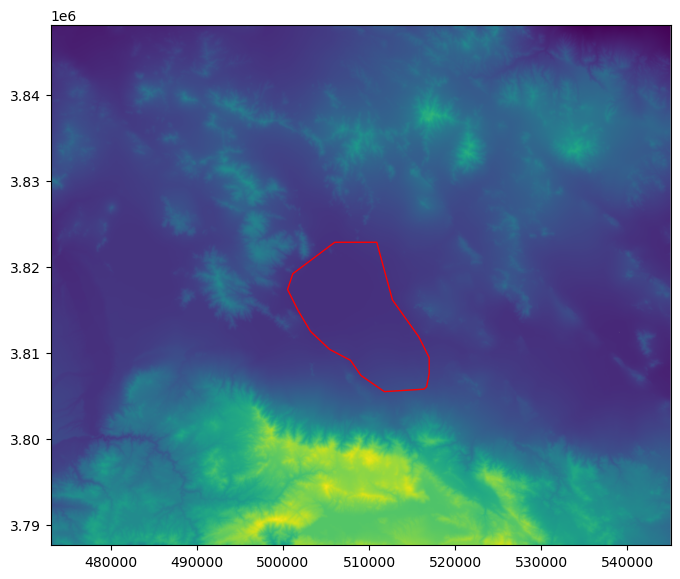

In [7]:
raster = flopy.utils.Raster.load(dem_data)

gdfaoi = gpd.read_file(study_area)
gdfaoi.head()

# inspect the raster and the grid boundary
fig, ax = plt.subplots(figsize=(8, 8))
raster.plot(ax=ax)
gdfaoi.plot(ax=ax, facecolor="None", edgecolor="red");

From the shapefile, we can get a bounding box of the study area which can be used to create model grid

In [9]:
xmin, ymin, xmax, ymax = gdfaoi.total_bounds

In the code block below define a `dx`, `dy` (cell size), calculate `nrow` and `ncol` from the model boundaries and the cell sizes, and finally create `delr` and `delc` arrays. The DIS package documentation can be found [here](https://modflow6.readthedocs.io/en/6.2.0/_mf6io/gwf-dis.html) for reference.

In [51]:
# Live code this
dx = 500
dy = 500
nrows = int(np.ceil((ymax - ymin) / dy))
ncols = int(np.ceil((xmax - xmin) / dx))
delc = np.full((nrows,), dy)
delr = np.full((ncols,), dx)

In [52]:
# nlay = 4
nlay = 3
xll = xmin
yll = ymin

### Creating an initial model grid instance

In the block below, create an initial model grid instance (it'll get deleted later). This model grid will be used to resample the DEM data to get the top array for the model and to intersect a shapefile that defines the active part of the model grid.

For a full representation of a model grid the following parameters are needed:

   - `delc`: row spacing in the column direction
   - `delr`: column spacing in the row direction
   - `top`: the model's top array. For the temporary grid any elevation can be provided as a 2d array of (nrow, ncol)
   - `botm`: the model's grid cell botm elevations. For the temporary grid this can be faked, but needs to be a 3d array with the dimensions (nlay, nrow, ncol)
   - `idomain`: the model's active and inactive extent. This can also be faked for the temporary grid. It'll be calculated later
   - `xoff`: the lower left corner of the model grid's x coordinate
   - `yoff`: the lower left corner of the model grid's y coordinate
   
Build a temporary model grid, called `fake_grid` in the block below. FloPy's `StructuredGrid()` object is used to create structured model grids.

In [53]:
crs = gdfaoi.crs

# Live code this, for simplicity use a single layer
fake_grid = StructuredGrid(
    delc=delc,
    delr=delr,
    top=np.ones((nrows, ncols)),
    botm=np.zeros((1, nrows, ncols)),
    idomain=np.ones((1, nrows, ncols), dtype=int),
    xoff=xll,
    yoff=yll,
    crs=crs
)

### Intersecting vector data with a modelgrid

The `GridIntersect` utility class allows users to intersect vector data (shapefile) with modelgrids and will return information about the intersection. In this example the study area boundary is intersected with the modelgrid instance that was created in the previous block to create an `idomain` array for the model.

In [54]:
# intersect and get the active cell id's
gix = flopy.utils.GridIntersect(fake_grid)

# get active cells
result = gix.intersect(gdfaoi.geometry.values[0], contains_centroid=True)
active_cellids = result.cellids
ixrow, ixcol = list(zip(*active_cellids))

C:\Users\jlarsen\Desktop\flopy-dev\flopy\utils\gridintersect.py:292: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(


Create an idomain array and then visualize it using FloPy's PlotMapView.

In [55]:
idomain = np.zeros((nlay, nrows, ncols), dtype=int)
idomain[:, ixrow, ixcol] = 1

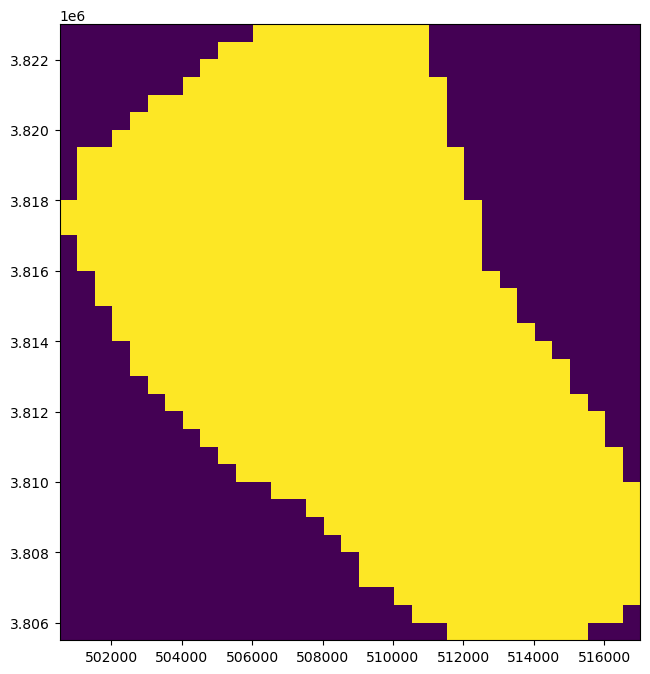

In [56]:
fig, ax = plt.subplots(figsize=(8, 8))

pmv = flopy.plot.PlotMapView(modelgrid=fake_grid)
pmv.plot_array(idomain);

### Resampling raster data

The `Raster` class has a `resample_to_grid()` method that allows the user to resample raster data a model grid and/or perform geostatics on rasters. 

There are three parameters that can be supplied to `resample_to_grid()`:
   - `modelgrid`: a flopy.discretization.Grid instance
   - `band`: the raster band to sample
   - `method`: resampling method (more information about the methods can be found [here](https://flopy.readthedocs.io/en/latest/Notebooks/raster_intersection_example.html)

In [57]:
# now we can create our dis file...
top = raster.resample_to_grid(
    fake_grid,
    band=raster.bands[0],
    method="min"
)
print(np.min(top), np.max(top))

# we'll use average thicknesses from the model to create our layer elevations
botm = np.zeros((nlay, nrows, ncols))
botm[0] = top - 50 # meters, alluvial fill
botm[1] = botm[0] - 20 # meters, historic lake deposits
botm[2] = botm[1] - 90 # meters, historic mojave alluvial and fluvial deposits

868.0 1150.0


### Create a DIS package

The `flopy.mf6.ModflowGwfdis()` package is used to create a structured rectalinier discretization package in FloPy. The preprocessing that has been done in the prior cells can be used to create this object. Parameters include:

   - `gwf`: the flopy model instance
   - `length_units`: the model length units
   - `xorigin`: the lower left corner x-coordinate
   - `yorigin`: the lower left corner y-coordinate
   - `nlay`: number of model layers
   - `nrow`: number of model rows
   - `ncol`: number of model columns
   - `delc`: row spacing in the column direction
   - `delr`: column spacing in the row direction
   - `top`: the model's top array. 
   - `botm`: the model's grid cell botm elevations.
   - `idomain`: the model's active and inactive extent.
   
Build a `flopy.mf6.ModflowGwfdis()` object

In [58]:
length_units = "meters"

# live code this
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    length_units=length_units,
    xorigin=xmin,
    yorigin=ymin,
    delc=delc,
    delr=delr,
    nlay=nlay,
    nrow=nrows,
    ncol=ncols,
    top=top,
    botm=botm,
    idomain=idomain
)


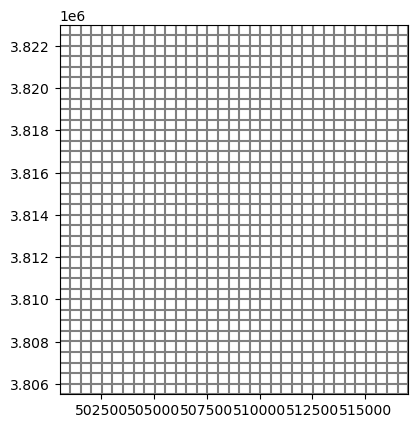

In [60]:
# remove the temporary model grid instance...
try:
    del fake_grid
except NameError:
    pass

# and get a copy of the actual model grid instance
modelgrid = gwf.modelgrid
modelgrid.plot();

### Making a NPF package

The Node Property Flow package (NPF) stores hydraulic parameters for the model (e.g., horizontal hydraulic conductivity). Often this data (and storage parameters) are estimated from geologic properties that were recorded in borehole data or from pumping tests.

For this example, we'll import a point shapefile with hyraulic conductivity estimates at each point location. This data can then be interpolated to the model grid to produce a hydraulic conductivity fields for our model. To actually do the interpolation, we'll use a premade function that sets the data to our modelgrid.


In [64]:
def interpolate_point_data(modelgrid, gdf, data_column):
    """
    Method to interpolate point cloud data to the modelgrid

    :param modelgrid: Flopy Grid object
    :param gdf: GeoDataFrame
    :param data_column: data column (values to interpolate)

    :return: np.array
    """

    import scipy.interpolate

    rxc, ryc = list(gdf.geometry.x), list(gdf.geometry.y)
    array = gdf[data_column].values

    xc, yc = modelgrid.xcellcenters.ravel(), modelgrid.ycellcenters.ravel()
    
    resampled_array = scipy.interpolate.griddata((rxc, ryc), array, (xc, yc), method="linear")

    # use nearest neighbor to fill any cells outside out the point cloud
    fill_array = scipy.interpolate.griddata((rxc, ryc), array, (xc, yc), method="nearest")
    resampled_array = np.where(np.isnan(resampled_array), fill_array, resampled_array)

    return resampled_array.reshape((modelgrid.nrow, modelgrid.ncol))
    

In [70]:
# Load the borehole shapefile with conductivity values
gdfhk = gpd.read_file(hk_file)
gdfhk.head()

,Id,hk1,hk2,hk3,geometry
0,0,0.2,0.01,2.0,POINT (511115.611 3805557.425)
1,0,0.2,0.01,2.0,POINT (514719.648 3810521.987)
2,0,1.5,0.01,16.0,POINT (515557.587 3814089.984)
3,0,1.5,0.01,16.0,POINT (512349.994 3816991.235)
4,0,0.1,0.01,0.5,POINT (506169.069 3809747.119)


In [71]:
# loop through the data columns and interpolate to a hk_array
hk_array = np.full(modelgrid.shape, 1e-10)

for ix, col in enumerate(["hk1", "hk2", "hk3"]):
    hk = interpolate_point_data(modelgrid, gdfhk, col)
    hk_array[ix] = hk

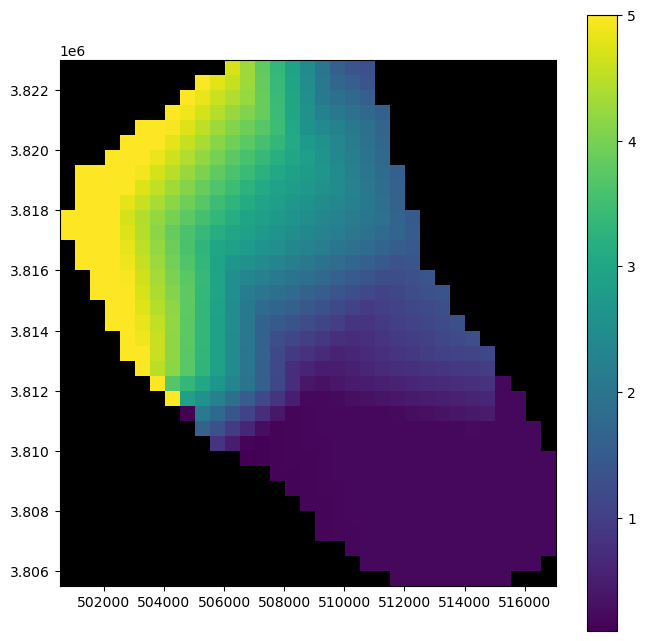

In [72]:
# And plot the data to confirm it's been interpolated properly
fig, ax = plt.subplots(figsize=(8, 8))
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid)
pc = pmv.plot_array(hk_array)
pmv.plot_inactive()
plt.colorbar(pc);

#### Build the node property flow package using `flopy.mf6.ModflowGwfnpf()`.

Four parameters are needed to build the node property flow package:
   - `gwf`: the flopy model object
   - `icelltype`: an array that defines if cells are confined or convertable. For this example, set all cells to confined storage
   - `k`: a horizontal conductivity array
   - `k33`: a vertical conductivity array. vk is unkown for this example however you could calculate a vk array using a vertical anisotropy factor...
   

In [74]:
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=1,
    k=hk_array,
    k33=hk_array * 0.1
)


## Initial Conditions

The basin initial condition is not well known, however we do know that there is limited exchange between the upper aquifer and the middle aquifer because of a lacustrine clay layer that acts as an aquitard between the two of them. For this model the intitial condition is set to the model top elevation.

In [76]:
strt = np.zeros(modelgrid.shape)
strt[:] = modelgrid.top

ic = flopy.mf6.ModflowGwfic(
    gwf,
    strt=strt
)

## Evapotranspiration from a historical lake bed. 

USGS records from Mendenhall (1909) and Thompson (1929) describe a limited amount of natural discharge from the basin from a few springs in the western part of the basin and by evapotranspiration of phreatophytes near the dry Lucerne Lake bed (playa). Near the southwest part of the lake bed cottonwood trees were observed and sparse pheatophytic vegetation was also observed in other parts of the area.

Phreatophytes in the Mojave deset can grow extremely long tap roots and have large root systems. Mesquite trees have the longest tap roots that can be up to 25 meters deep in some cases. Other phreatophytes have shorter tap roots. For example, the creosote bush has a tap root that extends to a depth of about 1 meter, and cottonwood trees can have tap roots that extend to a depth of about 5 meters.


In [ ]:
# with shapefile.Reader(lake_boundary) as r:
#     poly = r.shape(0)

# df = pd.read_csv(climate_file)
# df["year"] = df["Month Year"].apply(lambda x: x.split("-")[0])
# df = df.groupby(by=["year"], as_index=False)["Total ETo (mm)"].sum()
# eto = df["Total ETo (mm)"].mean() / (1000 * 365.25)
# print(eto)

Use `flopy.utils.GridIntersect` to intersect Lucerne Lake with the modelgrid and identify which model cells to simulate evapotranspiration from. 

The process is similar to what was done to identify the active model extent earlier in the notebook.

Using the cellids, create an evapotranspiration package. Remember to check if each cellid is within the active model extent as you build your evapotranspiration data records.

The `flopy.mf6.ModflowGwfevt()` class is used to build an EVT6 package. The class documentation can be found [here](https://flopy.readthedocs.io/en/latest/source/flopy.mf6.modflow.mfgwfevt.html). The necessary parameters are:
   - `model`
   - `maxbound`
   - `nseg`: this should be 1
   - `stress_period_data`: records of (cellid, surface, et_rate, et_depth, pxdp)

## Simulating Recharge in the model

The Lucerne Valley is located in the Mojave desert and recieves very little precipitation on the valley floor. Most of the recharge to this basin comes from snowmelt in the San Bernardino mountains to the south. Recharge estimates from the Basin Characterization Model (Flint et. al., 2013) estimate about 680 acre-ft of recharge to the basin.

A recharge zone has been mapped out by your friendly colleague that knows GIS. He got tired of working on code documentation and did this to help you out. When you inspect the shapefile you see that they got a little sloppy with tracing and 20% of the recharge area outside of the model boundaries.

With this information, a recharge package can be built for the model.

In [ ]:
# conv = 1233.48 # m3 per acre-ft

# with shapefile.Reader(recharge_boundary) as r:
#     poly = r.shape(0)

# recharge = 680 * 1.2 * conv / 365.25 # convert to m3/day and adjust by 1.2 for bad boundaries

Using `GridIntersect` identify the recharge cells and build a recharge package using `flopy.mf6.ModflowGwfrch()`.  The class documentation can be found [here](https://flopy.readthedocs.io/en/latest/source/flopy.mf6.modflow.mfgwfrch.html). The necessary parameters are:
   - `model`
   - `maxbound`
   - `stress_period_data`: records of (cellid, recharge_rate)

## Simulating model boundaries

Lucerne Valley is bounded on most sides by faults. The western part of the basin is bounded by the Helendale Fault system that runs southest to northwest and seperates the groundwater basin from the greater Mojave basin. In the north an unnamed fault runs east-west from the Granite mountains to the Ord mountains. In the southeast the Cougar Buttes Fault runs in a  southeast to northwest direction and separates the basin from the adjacent Johnson Valley aquifer system. The Cushenbury Fault, which is a splay off of the Helendale Fault, cuts across the southern part of the basin.

#### Note: with the exception of the Cushenbury Fault, these faults form the boundaries to this groundwater basin and can be represented as General Head boundaries
These faults have very low estimated conductivity. The Helendale fault and the unnamed northern fault conductivity is estimated to be around 1e-6. The Cougar Buttes fault provides slightly more exchange and has a conductivity between 1e-6 and 1e-5.

Heads across these faults are also higher than those in Lucerne Valley. Head on the west side of the Helendale fault is around 2900 ft asl, north of the unnamed fault is about 2890 ft asl and on the east side of the Cougar Buttes fault is about 2870 ft asl.


### Note2: the Cushenbury fault will be represented as a Horizontal flow barrier
The Cushenbury Fault zone has a hydraulic conductivity of about 1e-05

In this example, we'll build both a GHB and a HFB package

In [82]:
gdff = gpd.read_file(faults)
gdff.head()

,Id,fault_name,geometry
0,0,helendale,"LINESTRING (500528.115 3817373.489, 502851.423..."
1,0,north,"LINESTRING (505404.989 3822589.08, 510891.456 ..."
2,0,cougar,"LINESTRING (513014.369 3815541.711, 513870.937..."
3,0,cushenbury,"LINESTRING (507929.979 3809228.476, 508971.772..."


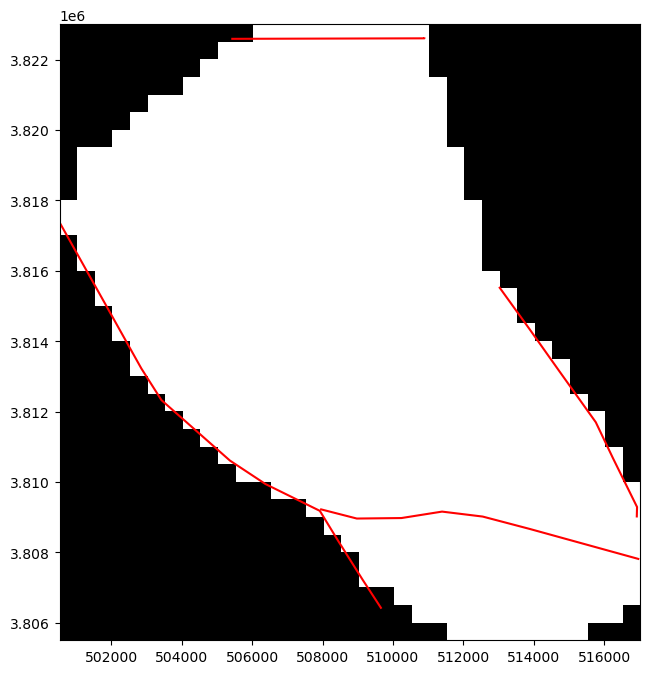

In [81]:
# visualize the faults on the modelgrid
fig, ax = plt.subplots(figsize=(8, 8))
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid, ax=ax)
pc = pmv.plot_ibound()
gdff.plot(ax=ax, color="red");

In [85]:
# get the ghb faults and intersect with the model grid
ghb_df = gdff[gdff.fault_name != "cushenbury"]

ghb_dict = {}
gix = flopy.utils.GridIntersect(modelgrid)
for name, geom in zip(ghb_df["fault_name"], ghb_df["geometry"]):
    result = gix.intersect(geom)
    ghb_dict[name] = list(result.cellids)


C:\Users\jlarsen\Desktop\flopy-dev\flopy\utils\gridintersect.py:292: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(
C:\Users\jlarsen\Desktop\flopy-dev\flopy\utils\gridintersect.py:292: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(
C:\Users\jlarsen\Desktop\flopy-dev\flopy\utils\gridintersect.py:292: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(


{'helendale': [(np.int64(11), np.int64(0)),
  (np.int64(12), np.int64(0)),
  (np.int64(13), np.int64(0)),
  (np.int64(13), np.int64(1)),
  (np.int64(14), np.int64(1)),
  (np.int64(14), np.int64(2)),
  (np.int64(15), np.int64(2)),
  (np.int64(16), np.int64(2)),
  (np.int64(16), np.int64(3)),
  (np.int64(17), np.int64(3)),
  (np.int64(18), np.int64(3)),
  (np.int64(18), np.int64(4)),
  (np.int64(19), np.int64(4)),
  (np.int64(20), np.int64(4)),
  (np.int64(20), np.int64(5)),
  (np.int64(21), np.int64(5)),
  (np.int64(21), np.int64(6)),
  (np.int64(22), np.int64(6)),
  (np.int64(22), np.int64(7)),
  (np.int64(23), np.int64(7)),
  (np.int64(23), np.int64(8)),
  (np.int64(24), np.int64(8)),
  (np.int64(24), np.int64(9)),
  (np.int64(25), np.int64(9)),
  (np.int64(25), np.int64(10)),
  (np.int64(25), np.int64(11)),
  (np.int64(26), np.int64(11)),
  (np.int64(26), np.int64(12)),
  (np.int64(26), np.int64(13)),
  (np.int64(27), np.int64(13)),
  (np.int64(27), np.int64(14)),
  (np.int64(27), np

#### Building the GHB package

Using the `ghb_cells` dictionary, we'll build a general head boundary condition package to represent faults on the edges of the model with `flopy.mf6.ModflowGwfghb()`. Head elevations and conductivity across the fault are as follows:
   - **helendale**: `k`=1e-06, `elev`=2900ft
   - **northern**: `k`=1e-06, `elev`=2890ft
   - **cougar**: `k`=3e-06`, `elev`=2870ft

Documentation for the `flopy.mf6.ModflowGwfghb()` class can be found [here](https://flopy.readthedocs.io/en/latest/source/flopy.mf6.modflow.mfgwfghb.html). Necessary input parameters are: 
   - `model`:
   - `stress_period_data`: records of (cellid, boundary_head, conductance)

In [90]:
# build the stress period data
cell_thick = modelgrid.cell_thickness
fault_info = {
    "helendale": [1e-06, 883.92],
    "north": [1e-06, 880.872],
    "cougar": [3e-06, 874.776]
}

records = []
for name, cellids in ghb_dict.items():
    k, bhead = fault_info[name]
    for lay in range(nlay):
        for row, col in cellids:
            thick = cell_thick[lay, row, col]
            cond = (k * thick * dx)
            records.append(((lay, row, col), bhead, cond))

records

[((0, np.int64(11), np.int64(0)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(12), np.int64(0)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(13), np.int64(0)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(13), np.int64(1)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(14), np.int64(1)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(14), np.int64(2)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(15), np.int64(2)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(16), np.int64(2)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(16), np.int64(3)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(17), np.int64(3)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(18), np.int64(3)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(18), np.int64(4)), 883.92, np.float64(0.024999999999999998)),
 ((0, np.int64(19), np.int64(4)), 883.92, np.float64(0.024999999999999998)),

now pass the record information to the GHB package constructor

In [ ]:
ghb = flopy.mf6.ModflowGwfghb(
    gwf,
    stress_period_data={0: records},
    pname="ghb_faults"
)

#### Building the HFB package

The final fault here can be represented as a horizontal flow barrier. For this we'll use the `make_hfb_array` utility in FloPy

In [91]:
df_hfb = gdff[gdff.fault_name == "cushenbury"]
df_hfb.head()

,Id,fault_name,geometry
3,0,cushenbury,"LINESTRING (507929.979 3809228.476, 508971.772..."


The `make_hfb_array` utility takes linestring information and returns a recarray of hfb records for FloPy's HFB package object

In [95]:
hfb_array = flopy.utils.make_hfb_array(modelgrid, df_hfb.geometry.values[0])
hfb_array["hydchr"] = 1e-05 * dx
hfb_array

C:\Users\jlarsen\Desktop\flopy-dev\flopy\utils\gridintersect.py:292: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(


rec.array([((np.int64(0), np.int64(27), np.int64(15)), (np.int64(0), np.int64(28), np.int64(15)), 0.005),
           ((np.int64(0), np.int64(27), np.int64(16)), (np.int64(0), np.int64(28), np.int64(16)), 0.005),
           ((np.int64(0), np.int64(27), np.int64(20)), (np.int64(0), np.int64(28), np.int64(20)), 0.005),
           ((np.int64(0), np.int64(27), np.int64(21)), (np.int64(0), np.int64(28), np.int64(21)), 0.005),
           ((np.int64(0), np.int64(27), np.int64(22)), (np.int64(0), np.int64(28), np.int64(22)), 0.005),
           ((np.int64(0), np.int64(27), np.int64(23)), (np.int64(0), np.int64(28), np.int64(23)), 0.005),
           ((np.int64(0), np.int64(28), np.int64(17)), (np.int64(0), np.int64(27), np.int64(17)), 0.005),
           ((np.int64(0), np.int64(28), np.int64(18)), (np.int64(0), np.int64(27), np.int64(18)), 0.005),
           ((np.int64(0), np.int64(28), np.int64(19)), (np.int64(0), np.int64(27), np.int64(19)), 0.005),
           ((np.int64(0), np.int64(28), np.int

now to build the HFB package

In [96]:
# live code
hfb = flopy.mf6.ModflowGwfhfb(
    gwf,
    stress_period_data={0: hfb_array},
    pname="cush_fault"
)

### Pumping in the basin


## Create an output control package

In [99]:
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    saverecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
    head_filerecord="lucerne_simple.hds",
    budget_filerecord="lucerne_simple.cbc",
    budgetcsv_filerecord="lucerne_simple.csv"
)

## Write the simulation to file and run the simulation

In [ ]:
sim.write_simulation()
sim.run_simulation()

## Load head results and plot

FloPy for modflow-6 has a `.output` attribute on the model object and many of the package objects. The `.output` attribute allows users to easily get head and budget information.

In [ ]:
# live coding


### Plot the head results

FloPy includes plotting utilities that allow users to easily plot model data. `PlotMapView` can be used to plot arrays, shapefile data, discharge vectors, and boundary conditions. 

An example tutorial on `PlotMapView` can be found [here](https://flopy.readthedocs.io/en/latest/Notebooks/plot_map_view_example.html). Plot up the head results and the inactive area of the model grid.